To access files stored in your Google Drive, you first need to mount your Drive to the Colab environment. This will prompt you to authenticate your Google account.

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once your Drive is mounted, you can use pandas to read your CSV file. Replace `'path/to/your/file.csv'` with the actual path to your CSV file within your Google Drive. For example, if your file is in a folder named `data` in your Drive, the path might be `'/content/drive/MyDrive/data/your_file.csv'`.

In [72]:
import pandas as pd
from matplotlib import pyplot as plt

# Replace 'path/to/your/file.csv' with the actual path to your CSV file in Google Drive
csv_file_path = '/content/drive/MyDrive/Colab Notebooks/loan_data.csv'
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [73]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [74]:
df.shape

(45000, 14)

In [75]:
df.duplicated().sum()

np.int64(0)

In [76]:
df2 = df.drop(["person_gender","person_education","person_age","loan_intent"],axis = 1)
df2.head(5)

,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71948,0,RENT,35000,16.02,0.49,3,561,No,1
1,12282,0,OWN,1000,11.14,0.08,2,504,Yes,0
2,12438,3,MORTGAGE,5500,12.87,0.44,3,635,No,1
3,79753,0,RENT,35000,15.23,0.44,2,675,No,1
4,66135,1,RENT,35000,14.27,0.53,4,586,No,1


In [93]:
(df["person_income"].describe())

,person_income
count,4.500000e+04
mean,8.031905e+04
std,8.042250e+04
min,8.000000e+03
25%,4.720400e+04
50%,6.704800e+04
75%,9.578925e+04
max,7.200766e+06


In [77]:
df2["person_home_ownership"].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [78]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df2["person_home_ownership"] = le.fit_transform(df2["person_home_ownership"])
df2.head(5)

,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71948,0,3,35000,16.02,0.49,3,561,No,1
1,12282,0,2,1000,11.14,0.08,2,504,Yes,0
2,12438,3,0,5500,12.87,0.44,3,635,No,1
3,79753,0,3,35000,15.23,0.44,2,675,No,1
4,66135,1,3,35000,14.27,0.53,4,586,No,1


In [79]:
le2 = LabelEncoder()
df2["previous_loan_defaults_on_file"] = le.fit_transform(df2["previous_loan_defaults_on_file"])
df2.head(5)

,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71948,0,3,35000,16.02,0.49,3,561,0,1
1,12282,0,2,1000,11.14,0.08,2,504,1,0
2,12438,3,0,5500,12.87,0.44,3,635,0,1
3,79753,0,3,35000,15.23,0.44,2,675,0,1
4,66135,1,3,35000,14.27,0.53,4,586,0,1


In [80]:
y = df2["loan_status"]
x = df2.drop("loan_status",axis = 1)

In [81]:
df2["loan_status"].value_counts(normalize=True)

,proportion
loan_status,
0,0.777778
1,0.222222


In [82]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
)

In [83]:
from sklearn.tree import DecisionTreeClassifier , plot_tree

id3_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    max_depth = 5
)
cart_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    max_depth = 5
)

In [84]:
id3_model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [85]:
cart_model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [86]:
y_prediction_id3 = id3_model.predict(x_test)
y_prediction_cart = cart_model.predict(x_test)

In [87]:
from sklearn.metrics import accuracy_score

accuracy_id3 = accuracy_score(y_test, y_prediction_id3)

print("Accuracy of ID3 :", accuracy_id3)

Accuracy of ID3 : 0.9103333333333333


In [88]:
accuracy_cart = accuracy_score(y_test, y_prediction_cart)

print("Accuracy of CART :", accuracy_cart)

Accuracy of CART : 0.9103333333333333


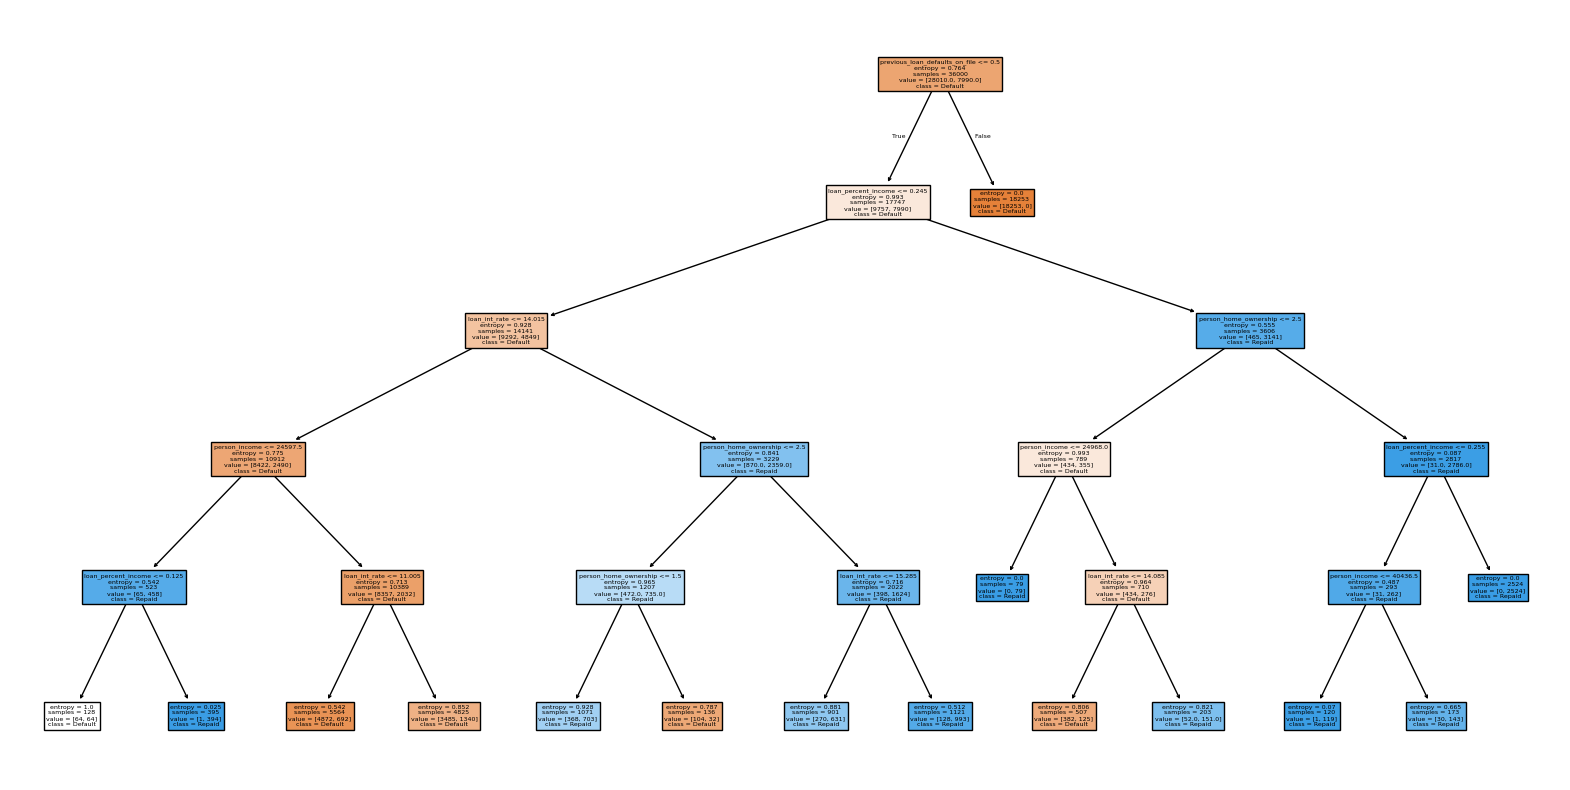

In [89]:
plt.figure(figsize=(20, 10))

plot_tree(
    id3_model,
    feature_names=x.columns,
    class_names=["Default", "Repaid"],
    filled=True
)

plt.show()